@author: chaoping

# Final project: Virginia state senate analysis
All data retrieved April 2025: <br>
[Population data](https://redistrictingdatahub.org/dataset/virginia-block-pl-94171-2020-by-table/): based on the decennial census at the Census Block level on 2020 Census Redistricting Data

[2020 County data](https://redistrictingdatahub.org/dataset/virginia-county-pl-94171-2020/): from 2020 Census Redistricting Data (P.L. 94-171) Shapefiles

[State Senate District data](https://redistrictingdatahub.org/dataset/2021-senate-of-virginia-districts-approved-plan/): 2021 State Senate Approved Plan

[2019 election data](https://redistrictingdatahub.org/dataset/vest-2019-virginia-state-senate-precinct-boundaries-and-election-results-shapefile/)**:**  VEST 2019 Virginia State Senate precinct boundaries and election results shapefile

[2017 election data](https://redistrictingdatahub.org/dataset/vest-2017-virginia-state-senate-special-precinct-boudaries-and-election-results-shapefile/)**:**  VEST 2017 Virginia State Senate special precinct boudaries and election results shapefile


In [1]:
import pandas as pd
import geopandas as gpd
import maup
from maup import smart_repair
import time
import os

In [2]:
import warnings
warnings.filterwarnings('ignore')

maup.progress.enabled = True

## Loading shape files and explore the data

In [3]:
# Load population file
population_df = gpd.read_file("./va_pl2020_b/va_pl2020_p2_b.shp")

#Load voting age population file
vap_df = gpd.read_file("./va_pl2020_b/va_pl2020_p4_b.shp")

#Load 2020 election data
vest19_df = gpd.read_file("./va_vest_19_statesenate/va_vest_19_statesenate.shp")

#Load county data
county_df = gpd.read_file("./va_pl2020_cnty/va_pl2020_cnty.shp")

#Load state senate district
sen_df = gpd.read_file("./va_sldu_adopted_2021/SCV FINAL SD.shp")

Check column names

In [4]:
print(population_df.columns)
print(vap_df.columns)
print(vest19_df.columns)
print(county_df.columns)
print(sen_df.columns)

Index(['GEOID20', 'SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'P0020001',
       'P0020002', 'P0020003', 'P0020004', 'P0020005', 'P0020006', 'P0020007',
       'P0020008', 'P0020009', 'P0020010', 'P0020011', 'P0020012', 'P0020013',
       'P0020014', 'P0020015', 'P0020016', 'P0020017', 'P0020018', 'P0020019',
       'P0020020', 'P0020021', 'P0020022', 'P0020023', 'P0020024', 'P0020025',
       'P0020026', 'P0020027', 'P0020028', 'P0020029', 'P0020030', 'P0020031',
       'P0020032', 'P0020033', 'P0020034', 'P0020035', 'P0020036', 'P0020037',
       'P0020038', 'P0020039', 'P0020040', 'P0020041', 'P0020042', 'P0020043',
       'P0020044', 'P0020045', 'P0020046', 'P0020047', 'P0020048', 'P0020049',
       'P0020050', 'P0020051', 'P0020052', 'P0020053', 'P0020054', 'P0020055',
       'P0020056', 'P0020057', 'P0020058', 'P0020059', 'P0020060', 'P0020061',
       'P0020062', 'P0020063', 'P0020064', 'P0020065', 'P0020066', 'P0020067',
       'P0020068', 'P0020069', 'P0020070', 'P0020071', 'P002

## Clean the data

First, we put everything into utm crs.

In [5]:
population_df = population_df.to_crs(population_df.estimate_utm_crs())
vap_df = vap_df.to_crs(vap_df.estimate_utm_crs())
county_df = county_df.to_crs(county_df.estimate_utm_crs())
sen_df = sen_df.to_crs(sen_df.estimate_utm_crs())
vest19_df = vest19_df.to_crs(vest19_df.estimate_utm_crs())

Check with maup.doctor()

In [6]:
maup.doctor(population_df)

100%|█████████████████████████████████| 163491/163491 [01:08<00:00, 2388.54it/s]


True

In [7]:
maup.doctor(vap_df)

100%|█████████████████████████████████| 163491/163491 [01:08<00:00, 2378.21it/s]


True

In [8]:
maup.doctor(county_df)

100%|████████████████████████████████████████| 133/133 [00:00<00:00, 221.70it/s]


True

In [9]:
maup.doctor(sen_df)

100%|██████████████████████████████████████████| 40/40 [00:00<00:00, 109.12it/s]


True

In [10]:
maup.doctor(vest19_df)

100%|██████████████████████████████████████| 2585/2585 [00:03<00:00, 762.08it/s]


There are 82 overlaps.
There are 546 holes.
There are some invalid geometries.


False

We need to do smart repair with our 2020 election data.

We first nest within counties.

In [11]:
vest19_df = smart_repair(vest19_df, nest_within_regions = county_df)

100%|████████████████████████████████████████| 133/133 [00:00<00:00, 217.32it/s]


Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.


100%|████████████████████████████████████████| 133/133 [00:00<00:00, 550.80it/s]


Identifying overlaps...


100%|█████████████████████████████████████| 2948/2948 [00:02<00:00, 1212.22it/s]


Resolving overlaps and filling gaps...


100%|████████████████████████████████████████| 133/133 [00:00<00:00, 555.56it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 2: 100%|███████████████| 2/2 [00:00<00:00,  2.54it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 4: 100%|██████████████| 1/1 [00:00<00:00, 138.99it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 7: 100%|███████████████| 2/2 [00:00<00:00, 78.74it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 9: 100%|███████████████| 1/1 [00:00<00:00, 57.64it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 10: 100%|███████

In [12]:
vest19_df = smart_repair(vest19_df, min_rook_length = 30)

Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|█████████████████████████████████████| 2636/2636 [00:00<00:00, 3632.67it/s]


Resolving overlaps...
Filling gaps...


Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


Converting small rook adjacencies to queen...


100%|███████████████████████████████████████████| 4/4 [00:00<00:00, 3019.11it/s]


In [13]:
maup.doctor(vest19_df)

100%|██████████████████████████████████████| 2585/2585 [00:03<00:00, 798.35it/s]


True

Visualize hte cleaned map

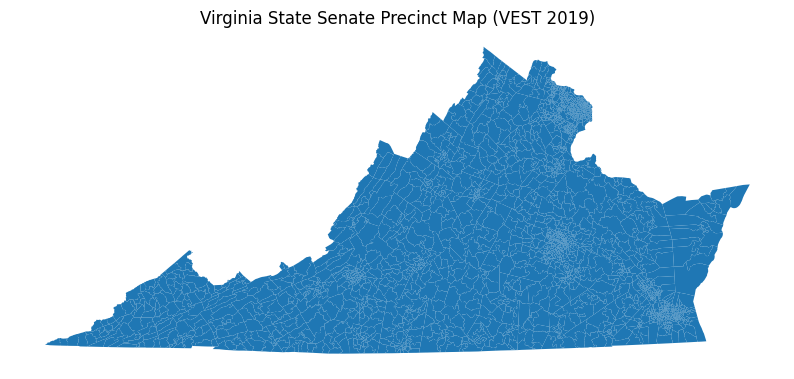

In [21]:
import matplotlib.pyplot as plt

vest19_df.plot(figsize=(10, 10))
plt.title("Virginia State Senate Precinct Map (VEST 2019)")
plt.axis("off")
plt.show()

save the shape file

In [17]:
directory = "./va_statesenate_19"
if not os.path.exists(directory):
    os.makedirs(directory)
vest19_df.to_file("./va_statesenate_19/va_statesenate_19.shp")

## Running Recom chain

The data is cleaned and we can run the recom chain now.

In [ ]:
shapefile_path = "./va_statesenate_19/va_statesenate_19.shp"
gdf = gpd.read_file(shapefile_path)